# 🚖 Taxi Trip Duration Prediction

## 📌 Project Overview
In this project, we aim to predict the duration of taxi trips using machine learning techniques. The dataset includes information about pickup and dropoff locations, timestamps, and passenger details.

## 🎯 Goal
The main objective is to build a model that can accurately estimate trip duration by leveraging time-based, geographical, and engineered features.

## 🧠 Approach
- Perform exploratory data analysis (EDA)  
- Engineer meaningful features (distance, time, cyclical encoding)  
- Train baseline and advanced models  
- Evaluate and compare performance  

## 🚀 Expected Outcome
We aim to demonstrate how feature engineering and model selection can significantly improve prediction performance.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))  

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.preprocessing import load_data, cleaning
from src.feature_engineering import prepare_features
from src.train import train_models
from src.evaluate import evaluate_models

sns.set(style="whitegrid")

In [3]:
df = load_data("../data/NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [5]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [6]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
df.duplicated().sum()

0

some problems I found

In [8]:
display(df[df['trip_duration']==1].head(2)) # it doesn’t make sense
display(df[df['passenger_count']==0].head(2)) # it also doesn’t make sense

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
35196,id2536510,1,2016-04-17 11:44:49,2016-04-17 11:44:50,1,-73.940384,40.786423,-73.940300,40.786373,N,1
207497,id1520236,1,2016-05-17 09:03:38,2016-05-17 09:03:39,1,-73.819893,40.740822,-73.819885,40.740822,N,1


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
62744,id3917283,2,2016-06-06 16:39:09,2016-06-07 16:30:50,0,-73.776367,40.645248,-73.776360,40.645260,N,85901
136519,id3645383,2,2016-01-01 05:01:32,2016-01-01 05:01:36,0,-73.993134,40.757473,-73.993294,40.757538,N,4


In [9]:
df = cleaning(df)

Q1: Is the trip duration normally distributed❓

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


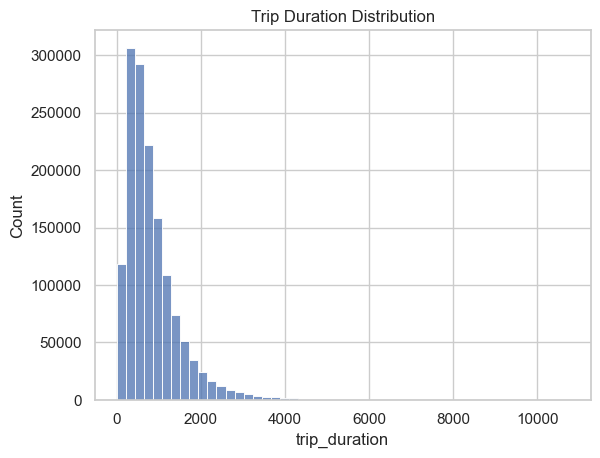

In [10]:
sns.histplot(df['trip_duration'], bins=50)
plt.title("Trip Duration Distribution")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


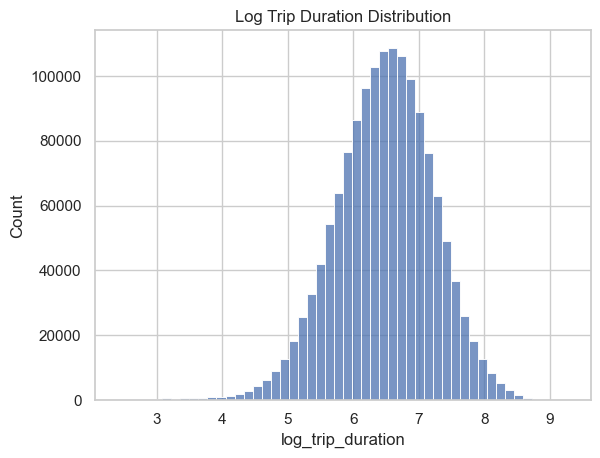

In [11]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])

sns.histplot(df['log_trip_duration'], bins=50)
plt.title("Log Trip Duration Distribution")
plt.show()

In [12]:
df = prepare_features(df)

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,pickup_hour,pickup_day,is_weekend,hour_sin,hour_cos,day_sin,day_cos,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,6.122493,17,0,0,-0.965926,-0.258819,0.000000,1.000000,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,6.498282,0,6,1,0.000000,1.000000,-0.781831,0.623490,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,7.661527,11,1,0,0.258819,-0.965926,0.781831,0.623490,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,6.063785,19,2,0,-0.965926,0.258819,0.974928,-0.222521,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,6.077642,13,5,1,-0.258819,-0.965926,-0.974928,-0.222521,1.188588


Q2: Does distance affect trip duration ❓

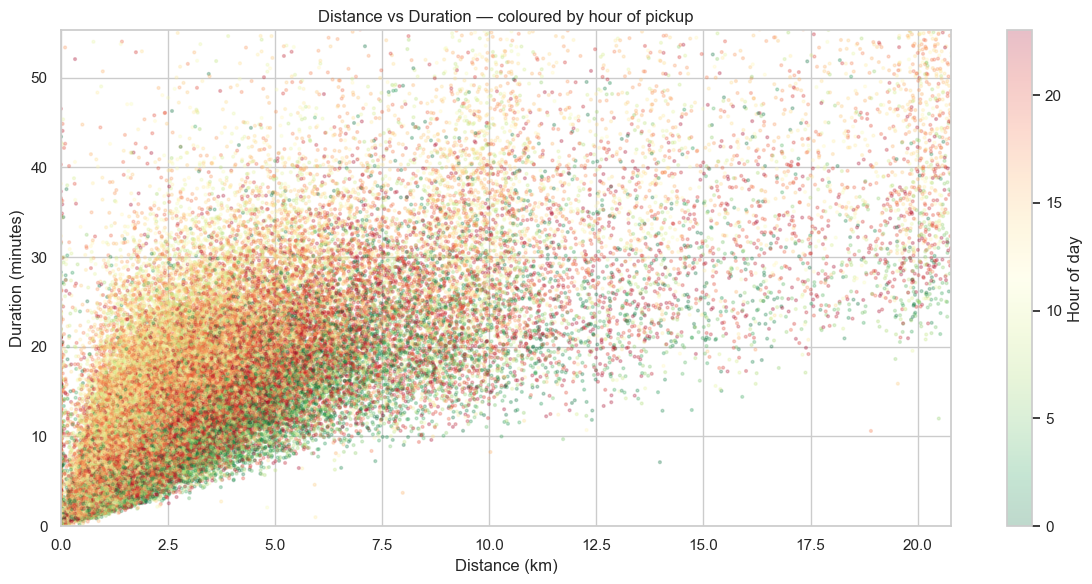

In [13]:
sample = df.sample(n=min(100_000, len(df)), random_state=42)

cap_dist = df['distance_km'].quantile(0.99)
cap_dur  = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    sample['distance_km'], sample['trip_duration'] / 60,
    c=sample['pickup_hour'], cmap='RdYlGn_r', alpha=0.25, s=4,
    vmin=0, vmax=23
)
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.set_xlim(0, cap_dist)
ax.set_ylim(0, cap_dur / 60)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Duration (minutes)")
ax.set_title("Distance vs Duration — coloured by hour of pickup")
plt.tight_layout()
plt.show()

Q3: Does the time of day affect trip duration❓

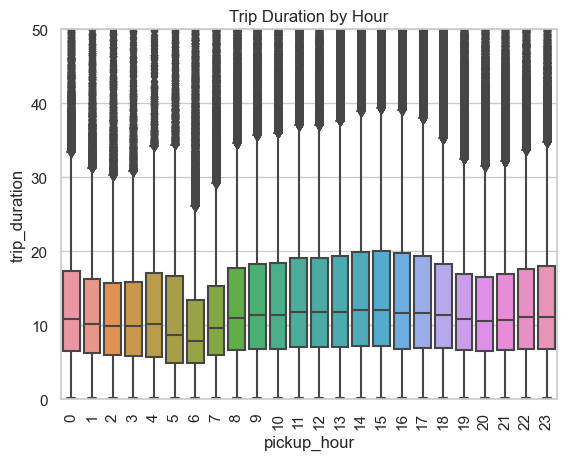

In [14]:
sns.boxplot(x=df['pickup_hour'], y=df['trip_duration'] / 60)
plt.title("Trip Duration by Hour")
plt.xticks(rotation=90)

plt.ylim(0, 50)  

plt.show()

Q4: Are weekends different from weekdays in terms of trip duration❓

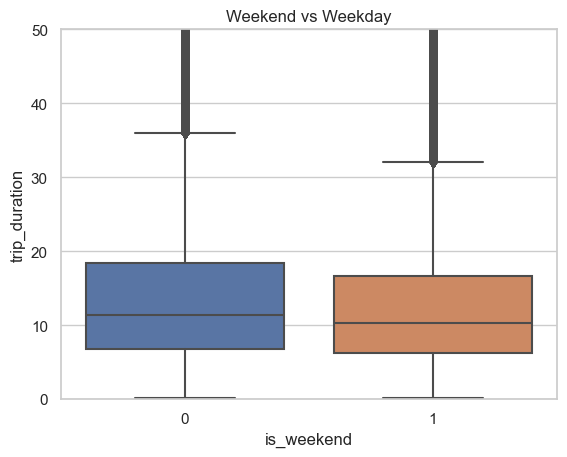

In [15]:
sns.boxplot(x=df['is_weekend'], y=df['trip_duration']/60)
plt.title("Weekend vs Weekday")

plt.ylim(0, 50) 

plt.show()

Q5: Does the number of passengers affect trip duration❓

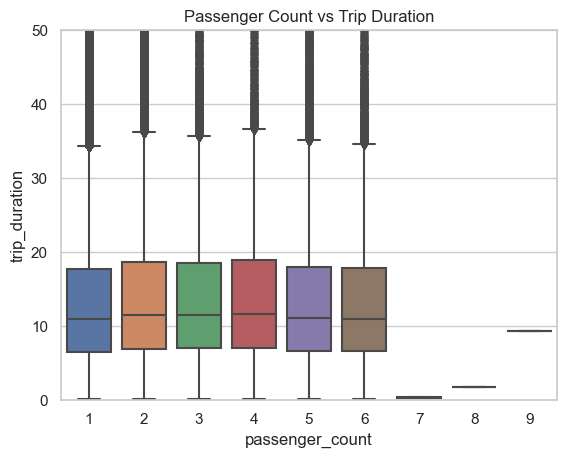

In [16]:
sns.boxplot(x=df['passenger_count'], y=df['trip_duration']/60)
plt.title("Passenger Count vs Trip Duration")

plt.ylim(0, 50) 

plt.show()

Q6: Which features are most correlated with the target variable❓

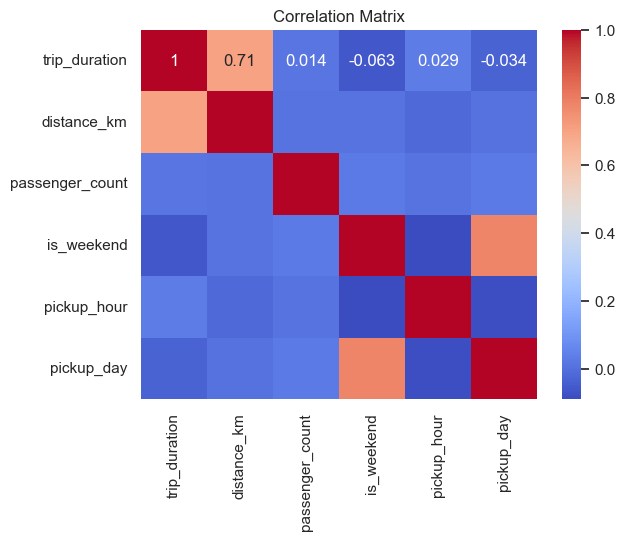

In [17]:
corr = df[['trip_duration', 'distance_km', 'passenger_count', 'is_weekend', 'pickup_hour', 'pickup_day']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Q7: How are trips distributed across different hours of the day ❓

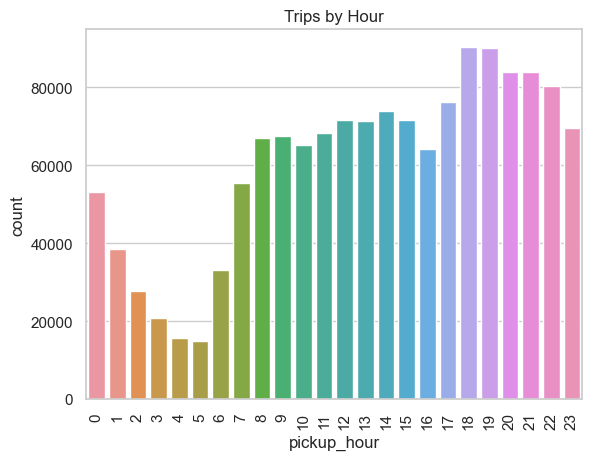

In [19]:
sns.countplot(x=df['pickup_hour'])
plt.title("Trips by Hour")
plt.xticks(rotation=90)
plt.show()

In [20]:
models, X_test, y_test = train_models(df)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [21]:
# evaluate
evaluate_models(models, X_test, y_test)


Model: LinearRegression
RMSE: 0.6284935062393123
MAE: 0.4321512401040145
R²: 0.30723914289525633

Model: XGBoost
RMSE: 0.36423145086009356
MAE: 0.25769754392652666
R²: 0.7673320095691187


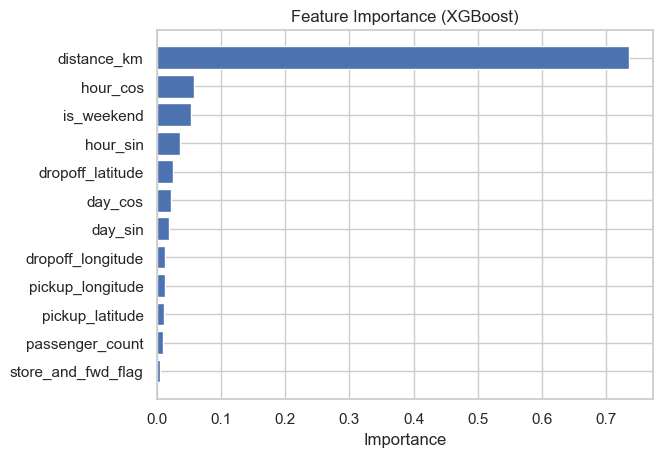

In [23]:
# Feature Importance (XGBoost)

model = models['XGBoost'] 

import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    'passenger_count',
    'is_weekend',
    'distance_km',
    'store_and_fwd_flag',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'pickup_latitude',
    'pickup_longitude',
    'dropoff_latitude',
    'dropoff_longitude'
]

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# plot
plt.figure()
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

 Distance is the most important feature affecting trip duration 

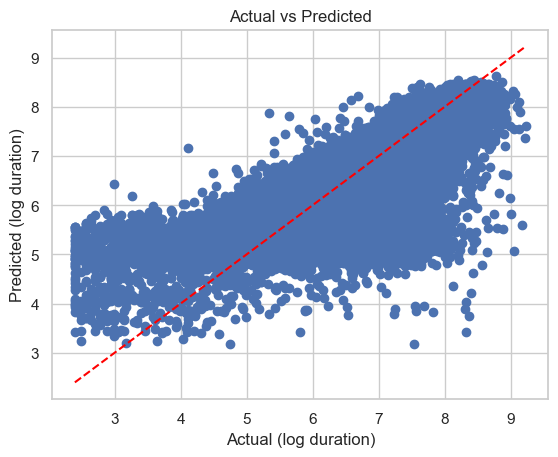

In [25]:
model = models['XGBoost']
y_pred = model.predict(X_test)

plt.figure()

# scatter plot
plt.scatter(y_test, y_pred)

# reference line (perfect predictions)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color = 'red')

plt.xlabel("Actual (log duration)")
plt.ylabel("Predicted (log duration)")
plt.title("Actual vs Predicted")

plt.show()